# Stock Price Prediction Analysis - Simplified Version

This notebook demonstrates stock price prediction using LSTM and GRU neural networks in a simple, step-by-step way.

## What We'll Do:
1. Load and explore stock data
2. Prepare the data for training
3. Build LSTM and GRU models
4. Train the models
5. Compare results

## Step 1: Import Libraries

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# # Set plot style
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")


## Step 2: Load the Data

We'll download the data directly from Yahoo Finance. This works both locally and in Google Colab.

In [174]:
# Import yfinance for downloading stock data
import yfinance as yf

# Download Adani Ports data from Yahoo Finance
ticker = "ADANIPORTS.NS"
start_date = "2021-03-28"
end_date = "2026-03-28"

print(f"Downloading {ticker} data from Yahoo Finance...")
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns (newer yfinance versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    
    # Rename columns for easier access
    df.rename(columns={
        'Close_ADANIPORTS.NS': 'Close',
        'Open_ADANIPORTS.NS': 'Open', 
        'High_ADANIPORTS.NS': 'High',
        'Low_ADANIPORTS.NS': 'Low',
        'Volume_ADANIPORTS.NS': 'Volume'
    }, inplace=True)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Display first few rows
print("\nFirst 5 rows of the data:")
df.head()


[*********************100%***********************]  1 of 1 completed


First 5 rows of the data:


,Close,High,Low,Open,Volume
Date,,,,,
2021-03-30,689.743164,696.975020,676.881160,682.462784,9109273
2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2021-04-01,714.690613,720.272237,684.355697,692.606794,15017049
2021-04-05,720.515015,723.184488,694.062965,710.322482,15622924
2021-04-06,811.082886,827.730712,721.243005,733.862331,64555516


In [3]:
# Check data info
print("\nData Information:")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")



Data Information:
Shape: (1236, 5)

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
# Basic statistics
print("\nStatistical Summary:")
df.describe()



Statistical Summary:


,Close,High,Low,Open,Volume
count,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,1017.986080,1033.057941,1004.147551,1019.900044,6.444519e+06
std,316.754664,318.869138,314.626066,317.169819,9.400372e+06
min,455.184814,499.034926,388.892904,451.789016,0.000000e+00
25%,727.237991,736.853009,718.605363,728.197708,2.258730e+06
50%,858.989716,874.246229,845.399059,859.038928,3.710298e+06
75%,1354.515869,1372.454579,1334.044864,1354.151770,6.655277e+06
max,1582.451172,1606.656534,1560.905968,1575.900024,1.155175e+08


## Step 3: Visualize the Stock Data

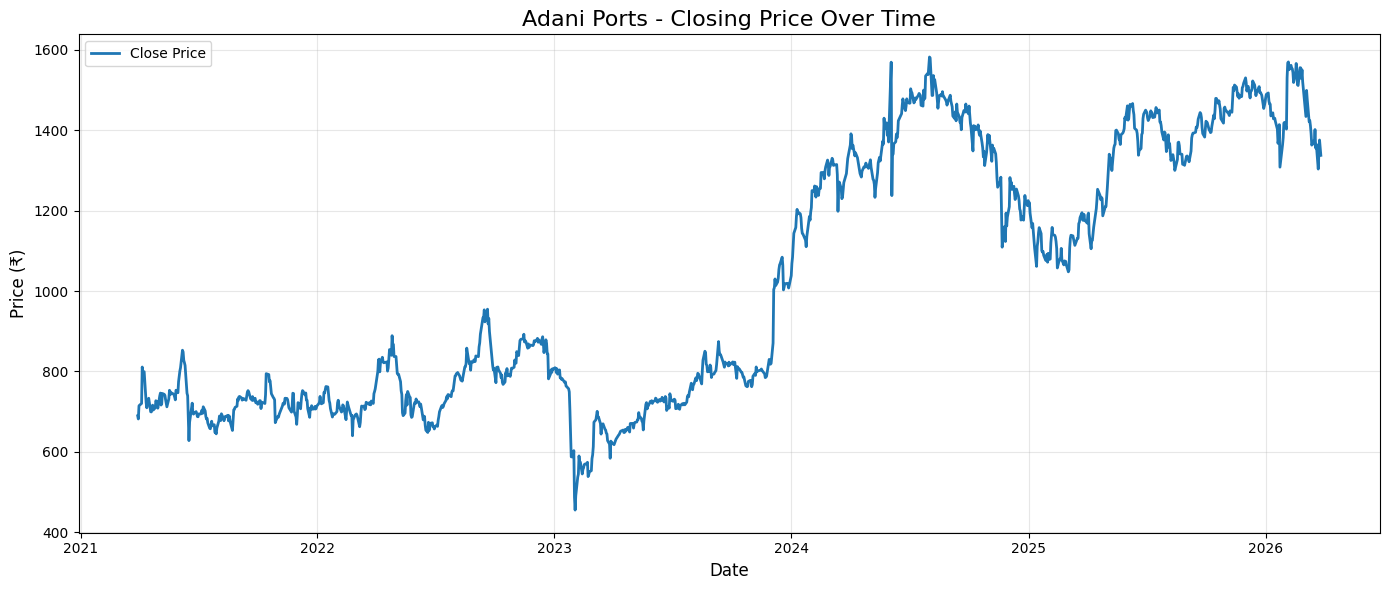

In [5]:
# Plot closing prices over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.title('Adani Ports - Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


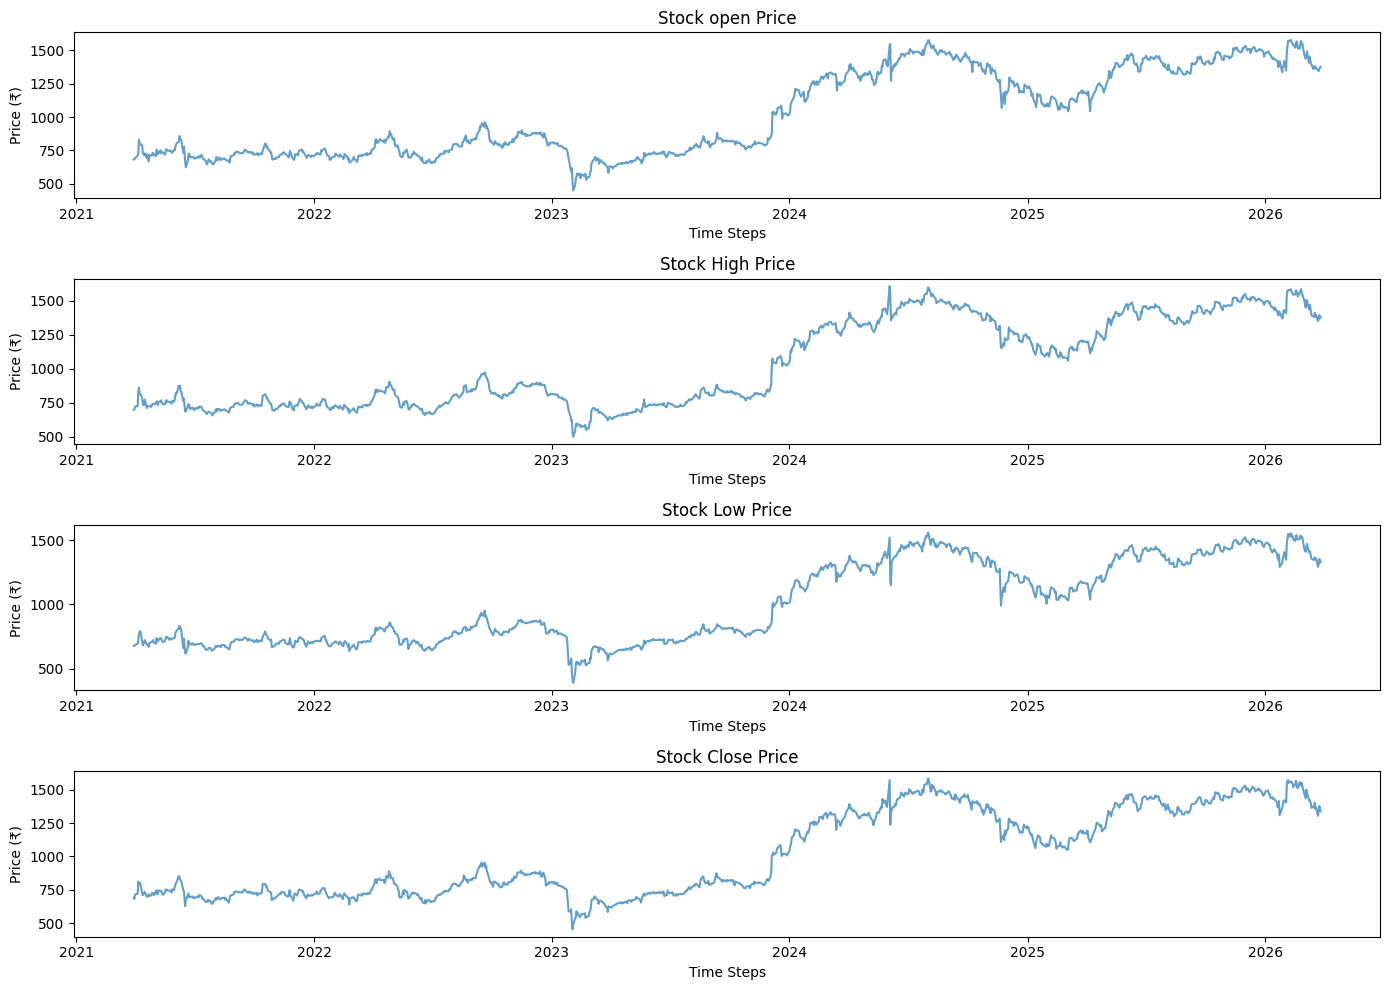

In [7]:
# Plot all OHLC data
fig,axes =plt.subplots(4,1,figsize=(14,10))

axes[0].plot(df.index, df['Open'], label='Open', alpha=0.7)
axes[0].set_title("Stock open Price")
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price (₹)')

axes[1].plot(df.index, df['High'], label='High', alpha=0.7)
axes[1].set_title("Stock High Price")
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Price (₹)')

axes[2].plot(df.index, df['Low'], label='Low', alpha=0.7)
axes[2].set_title("Stock Low Price")
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Price (₹)')

axes[3].plot(df.index, df['Close'], label='Close', alpha=0.7)
axes[3].set_title("Stock Close Price")
axes[3].set_xlabel('Time Steps')
axes[3].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()


## Step 4: Prepare the Data for Training

We need to:
1. Handle missing values
2. Normalize the data (scale between 0 and 1)
3. Create sequences for time series prediction

In [8]:
# Handle missing values - forward fill then backward fill
df_clean = df.fillna(method='ffill').fillna(method='bfill')

# Check if any missing values remain
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")


Missing values after cleaning: 0


In [15]:
# Select features to use for prediction
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df_clean[feature_columns].values

print(f"Data shape: {data.shape}")
print(f"Close price range: ₹{data[:, 3].min():.2f} - ₹{data[:, 3].max():.2f}")


Data shape: (1236, 5)
Close price range: ₹455.18 - ₹1582.45


In [25]:
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

feature_data = df[feature_columns].to_numpy()
target_data = df[["Close"]].to_numpy()
target_idx = feature_columns.index("Close")

In [26]:
feature_data.shape , target_data.shape

((1236, 5), (1236, 1))

In [27]:
target_data


array([[ 689.74316406],
       [ 681.83190918],
       [ 714.69061279],
       ...,
       [1344.19995117],
       [1375.90002441],
       [1337.80004883]])

In [ ]:
data[1:1+10]

array([[6.84355751e+02, 6.98819463e+02, 6.78143136e+02, 6.81831909e+02,
        7.75222600e+06],
       [6.92606794e+02, 7.20272237e+02, 6.84355697e+02, 7.14690613e+02,
        1.50170490e+07],
       [7.10322482e+02, 7.23184488e+02, 6.94062965e+02, 7.20515015e+02,
        1.56229240e+07],
       [7.33862331e+02, 8.27730712e+02, 7.21243005e+02, 8.11082886e+02,
        6.45555160e+07],
       [8.31904776e+02, 8.59084862e+02, 7.71720300e+02, 7.90891968e+02,
        9.77178800e+07],
       [7.94046864e+02, 8.13461213e+02, 7.82398255e+02, 7.98900452e+02,
        3.40258730e+07],
       [8.00599137e+02, 8.12490424e+02, 7.93124601e+02, 7.99482788e+02,
        2.18047850e+07],
       [7.86184036e+02, 7.86184036e+02, 7.13477280e+02, 7.22844727e+02,
        2.81122400e+07],
       [7.28038114e+02, 7.33619739e+02, 6.80812684e+02, 7.09643005e+02,
        5.28125170e+07],
       [7.14350928e+02, 7.32406247e+02, 7.03770085e+02, 7.28377747e+02,
        2.61086140e+07]])

In [31]:
data[1:1+10,0]

array([684.35575066, 692.6067942 , 710.3224816 , 733.8623309 ,
       831.90477617, 794.04686447, 800.59913674, 786.18403612,
       728.03811356, 714.35092814])

In [32]:

SEQUENCE_LENGTH = 100

X = []
y = []

# Close price is at index 3 in our feature_columns
CLOSE_INDEX = 3

for i in range(len(data)-SEQUENCE_LENGTH):
    
    X.append(data[i:i+SEQUENCE_LENGTH]) # Get the sequence of past days
    
    y.append(data[i + SEQUENCE_LENGTH][CLOSE_INDEX]) # Get the next day's close price

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")  # (samples, timesteps, features)
print(f"y shape: {y.shape}")  # (samples,)


X shape: (1136, 100, 5)
y shape: (1136,)


In [45]:
X_train_raw,X_test_raw,y_train_raw,y_test_raw=train_test_split(X,y,test_size=0.2,shuffle=False,random_state=42)

print(f"Training set size: {len(X_train_raw)}")
print(f"Testing set size: {len(X_test_raw)}")


Training set size: 908
Testing set size: 228


In [51]:
X_train_raw.shape , y_train_raw.shape

((908, 100, 5), (908,))

In [52]:
# NOW normalize - fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))


In [61]:
# Reshape for scaling: (samples, timesteps, features) -> (samples*timesteps, features)
n_train_samples, n_timesteps, n_features = X_train_raw.shape
n_test_samples = X_test_raw.shape[0]

# Fit scaler on training data only
X_train_reshaped = X_train_raw.reshape(-1, n_features)
scaler.fit(X_train_reshaped)

MinMaxScaler()

In [73]:
# Transform both train and test using the SAME scaler (fit on train only!)
X_train = scaler.transform(X_train_reshaped).reshape(n_train_samples, n_timesteps, n_features)
X_test = scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(n_test_samples, n_timesteps, n_features)


In [74]:
# Scale y values with a dedicated scaler (fit on train only)
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).reshape(-1)
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).reshape(-1)

In [75]:
print(X_train.shape)
print(y_train.shape)

(908, 100, 5)
(908,)


In [76]:
print(X_test.shape)
print(y_test.shape)

(228, 100, 5)
(228,)


## Step 5: Build the LSTM Model

LSTM (Long Short-Term Memory) is a type of recurrent neural network good at learning long-term dependencies.

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# Create LSTM model architecture
lstm_model = Sequential()

# First LSTM layer 
lstm_model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Second LSTM layer 
lstm_model.add(LSTM(units=100,return_sequences=True))

# 3rd LSTM layer
lstm_model.add(LSTM(units=50,return_sequences=False))

# Output layer
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 100)       │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,051 (597.86 KB)

 Trainable params: 153,051 (597.86 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the LSTM Model

In [80]:
# Set training parameters
EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 15  # Early stopping patience

# Create callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\nLSTM training completed!")


Training LSTM model...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0448 - val_loss: 0.0085
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0060 - val_loss: 0.0077
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029 - val_loss: 0.0050
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 12/100
15/15 ━━━━━━━━━━

In [ ]:
X_train_lstm_predictions = lstm_model.predict(X_train)
X_test_lstm_predictions = lstm_model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [97]:
train_predict=y_scaler.inverse_transform(X_train_lstm_predictions)
test_predict=y_scaler.inverse_transform(X_test_lstm_predictions)


In [107]:
X_train_raw.reshape(-1).shape,train_predict.shape

((454000,), (908, 1))

In [109]:
pd.DataFrame({
    "Actual_Train": y_train_raw,  # Use y_train instead of X_train_raw
    "Train_predict": train_predict.reshape(-1) # Flattens to (908,)
})


,Actual_Train,Train_predict
0,704.546143,674.213806
1,705.474731,682.763672
2,710.655579,699.585876
3,713.588135,714.913452
4,731.476624,724.459534
...,...,...
903,1233.100708,1240.808472
904,1230.413818,1231.437012
905,1187.223999,1229.236206
906,1204.042114,1209.459839


In [111]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test, X_test_lstm_predictions))
lstm_mae = mean_absolute_error(y_test, X_test_lstm_predictions)
lstm_r2 = r2_score(y_test, X_test_lstm_predictions)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [lstm_rmse],
    'MAE': [lstm_mae],
    'R² Score': [lstm_r2]
})
comparison_df

,Model,RMSE,MAE,R² Score
0,LSTM,0.024067,0.017811,0.832587


In [112]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_raw, test_predict))
lstm_mae = mean_absolute_error(y_test_raw, test_predict)
lstm_r2 = r2_score(y_test_raw, test_predict)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [lstm_rmse],
    'MAE': [lstm_mae],
    'R² Score': [lstm_r2]
})
comparison_df

,Model,RMSE,MAE,R² Score
0,LSTM,27.130229,20.077286,0.832587


In [118]:
# Create a dataframe for comparison
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LSTM_Prediction': X_test_lstm_predictions.flatten(),
})

print("Predictions sample:")
predictions_df.head(10)

Predictions sample:


,Actual,LSTM_Prediction
0,0.670139,0.663602
1,0.711278,0.671625
2,0.785434,0.701674
3,0.762216,0.752904
4,0.777577,0.777279
5,0.773074,0.772320
6,0.749415,0.774584
7,0.798676,0.756659
8,0.804944,0.780459
9,0.807239,0.796575


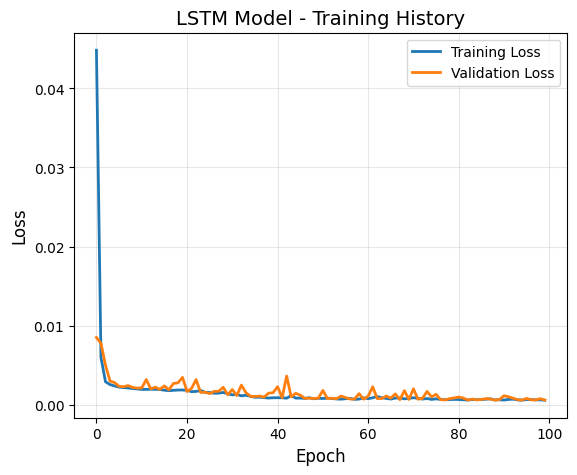

In [116]:
# Plot training history for LSTM
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


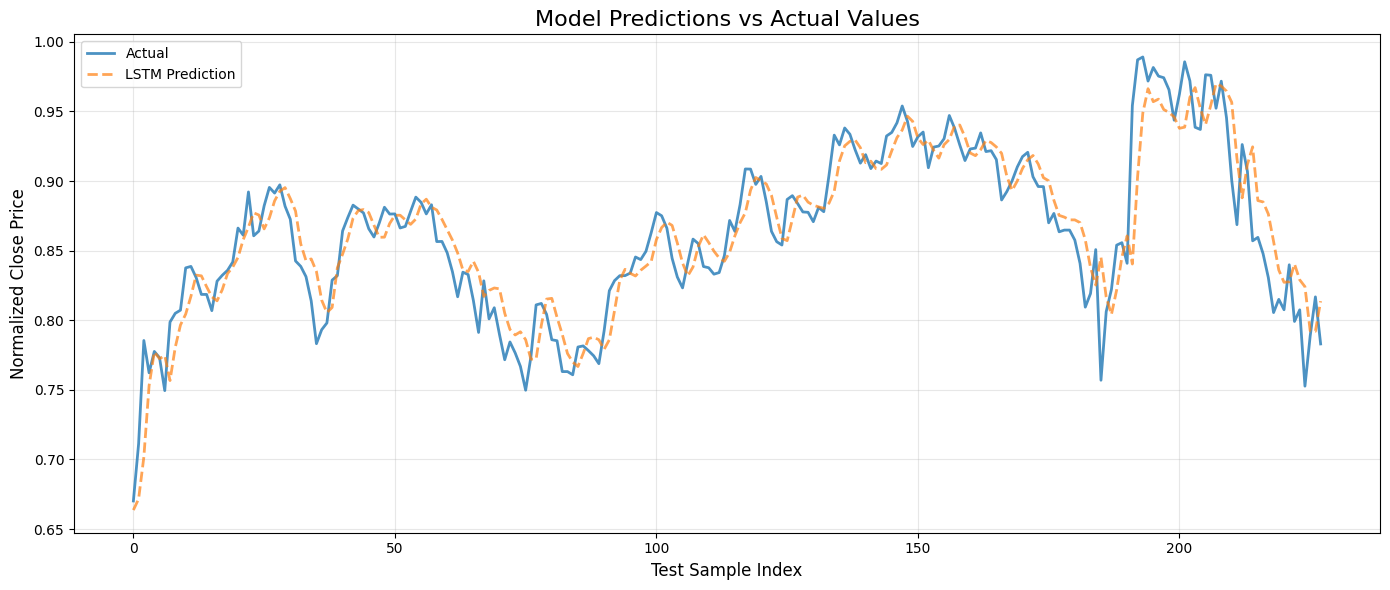

In [ ]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df.index, predictions_df['LSTM_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [179]:
scaler_for_prices = y_scaler          # dedicated scaler for the target variable
length_of_sequence = SEQUENCE_LENGTH  
past_data = X_test                    # testing dataset (scaled)
close_idx = CLOSE_INDEX               # From notebook (Close index = 3)

# Grab the VERY LAST sequence available from X_test to act as our launching pad
current_window = past_data[-1].copy() 

# List to store future predictions
predicted_prices_list = []
days_to_guess = 7

# --- STEP 2: THE RECURSIVE PREDICTION LOOP ---
for i in range(days_to_guess):
    
    # 1. Reshape window for the model: (1 batch, 100 timesteps, 5 features)
    input_for_model = current_window.reshape(1, length_of_sequence, -1)
    
    # 2. Get the raw (scaled) prediction from the LSTM
    raw_prediction = lstm_model.predict(input_for_model, verbose=0)
    
    # 3. Inverse transform directly (Works because y_scaler was fit on 1 feature)
    real_price = scaler_for_prices.inverse_transform(raw_prediction).reshape(-1)[0]
    predicted_prices_list.append(real_price)
    
    # 4. Update the sliding window
    # Copy the features of the last day in the window
    last_row = current_window[-1].copy()
    
    # Overwrite the 'Close' feature with our new raw prediction
    last_row[close_idx] = raw_prediction.reshape(-1)[0]
    
    # Shift window: drop the oldest day (index 0) and append our newly constructed day
    current_window = np.vstack([current_window[1:], last_row.reshape(1, -1)])

# --- STEP 3: GENERATE FUTURE BUSINESS DATES ---
# Find the exact last date in your original dataframe
last_known_date = df.index[-1]

# Generate the next 7 'Business' days (skipping weekends)
future_dates = pd.date_range(start=last_known_date + timedelta(days=1), 
                             periods=days_to_guess, 
                             freq='B')

# --- STEP 4: DISPLAY RESULTS ---
results_table = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m-%d'), # Clean date formatting
    'Predicted_Close_Price ($)': np.round(predicted_prices_list, 2) # Round to 2 decimal places
})

print(f"\n--- LSTM Predictions for the Next {days_to_guess} Business Days ---")
print(results_table.to_string(index=False))



--- LSTM Predictions for the Next 7 Business Days ---
      Date  Predicted_Close_Price ($)
2026-03-30                1372.449951
2026-03-31                1380.300049
2026-04-01                1381.689941
2026-04-02                1381.140015
2026-04-03                1380.000000
2026-04-06                1378.709961
2026-04-07                1377.469971


In [182]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Visualize future predictions (Simple Version)
plt.figure(figsize=(14, 7))

# Plot last 100 days of historical data
historical_close = df_clean['Close'].values[-100:]
historical_dates = df_clean['Date'].values[-100:]

# Historical data
plt.plot(historical_dates, historical_close, 'b-', label='Historical', linewidth=2)

# Future predictions
plt.plot(future_predictions['Date'], future_predictions['Predicted_Close'], 
         'r--o', label='Predicted', linewidth=2, markersize=5)

# Vertical line at prediction start
plt.axvline(x=historical_dates[-1], color='gray', linestyle=':', alpha=0.5)

# Labels and title
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.title(f'Stock Price Forecast - Next {DAYS_TO_PREDICT} Days', fontsize=14, fontweight='bold')

# Legend and grid
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')

# Format dates on x-axis
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print simple summary
current_price = historical_close[-1]
predicted_end = future_predictions['Predicted_Close'].iloc[-1]
change_pct = ((predicted_end - current_price) / current_price) * 100

print(f"\n📊 Quick Summary:")
print(f"   Current Price:  ₹{current_price:.2f}")
print(f"   Predicted Price: ₹{predicted_end:.2f}")
print(f"   Expected Change: {change_pct:+.2f}%")

KeyError: 'Date'

<Figure size 1400x700 with 0 Axes>

## Step 7: Build the GRU Model

GRU (Gated Recurrent Unit) is similar to LSTM but with a simpler architecture.

In [ ]:
from tensorflow.keras.layers import GRU

# Create GRU model architecture
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.2))

# Second GRU layer with dropout
gru_model.add(GRU(units=50))
gru_model.add(Dropout(0.2))

# Dense layer
gru_model.add(Dense(units=50, activation='relu'))

# Output layer
gru_model.add(Dense(units=1))

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Display model summary
gru_model.summary()


## Step 8: Train the GRU Model

In [ ]:
# Train the GRU model
print("Training GRU model...")

gru_checkpoint = ModelCheckpoint(
    filepath='../models/gru_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, gru_checkpoint],
    verbose=1
)

print("\nGRU training completed!")


## Step 9: Make Predictions

In [40]:
# Make predictions with both models
lstm_predictions = lstm_model.predict(X_test)
gru_predictions = gru_model.predict(X_test)

# Create a dataframe for comparison
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LSTM_Prediction': lstm_predictions.flatten(),
    'GRU_Prediction': gru_predictions.flatten()
})

print("Predictions sample:")
predictions_df.head(10)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions sample:


,Actual,LSTM_Prediction,GRU_Prediction
0,0.691161,0.684449,0.637749
1,0.714676,0.688416,0.653991
2,0.705980,0.693504,0.667465
3,0.697550,0.699039,0.677858
4,0.695687,0.704378,0.684131
5,0.694178,0.709558,0.688237
6,0.651408,0.713514,0.687615
7,0.672616,0.716127,0.682629
8,0.675366,0.718236,0.679254
9,0.710771,0.719938,0.677524


## Step 10: Evaluate the Models

In [41]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)

# Calculate evaluation metrics for GRU
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))
gru_mae = mean_absolute_error(y_test, gru_predictions)
gru_r2 = r2_score(y_test, gru_predictions)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'RMSE': [lstm_rmse, gru_rmse],
    'MAE': [lstm_mae, gru_mae],
    'R² Score': [lstm_r2, gru_r2]
})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Determine the best model
best_model = 'LSTM' if lstm_r2 > gru_r2 else 'GRU'
print(f"\n✓ Best performing model based on R² Score: {best_model}")



Model Comparison:
Model     RMSE      MAE  R² Score
 LSTM 0.040295 0.031663  0.636743
  GRU 0.033022 0.025594  0.756033

✓ Best performing model based on R² Score: GRU


## Step 11: Visualize Training History

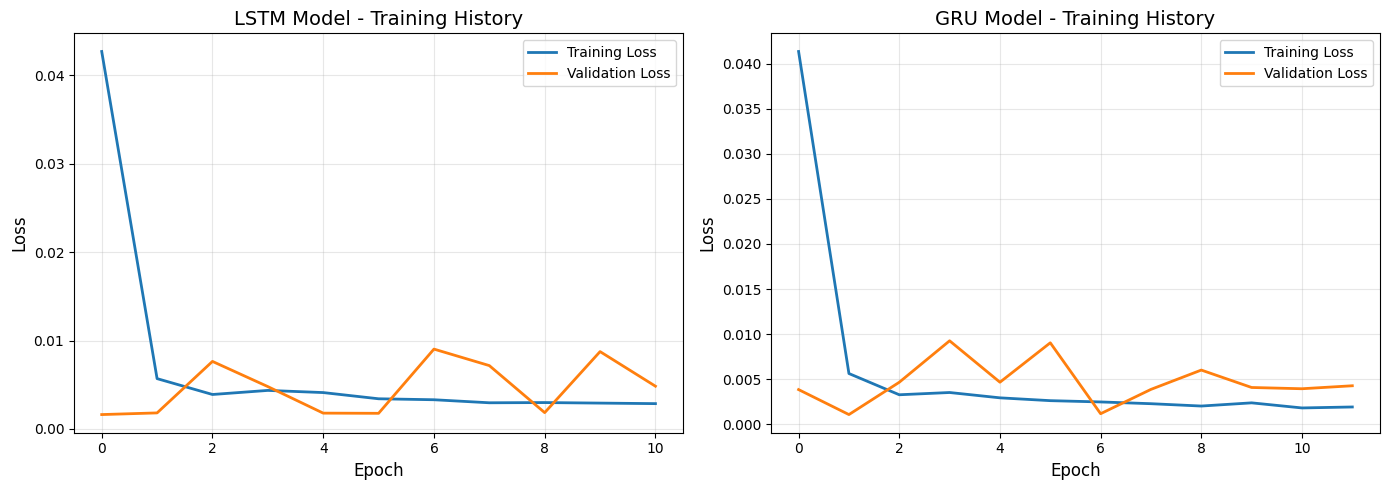

In [42]:
# Plot training history for LSTM
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training history for GRU
plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(gru_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('GRU Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Visualize Predictions vs Actual Values

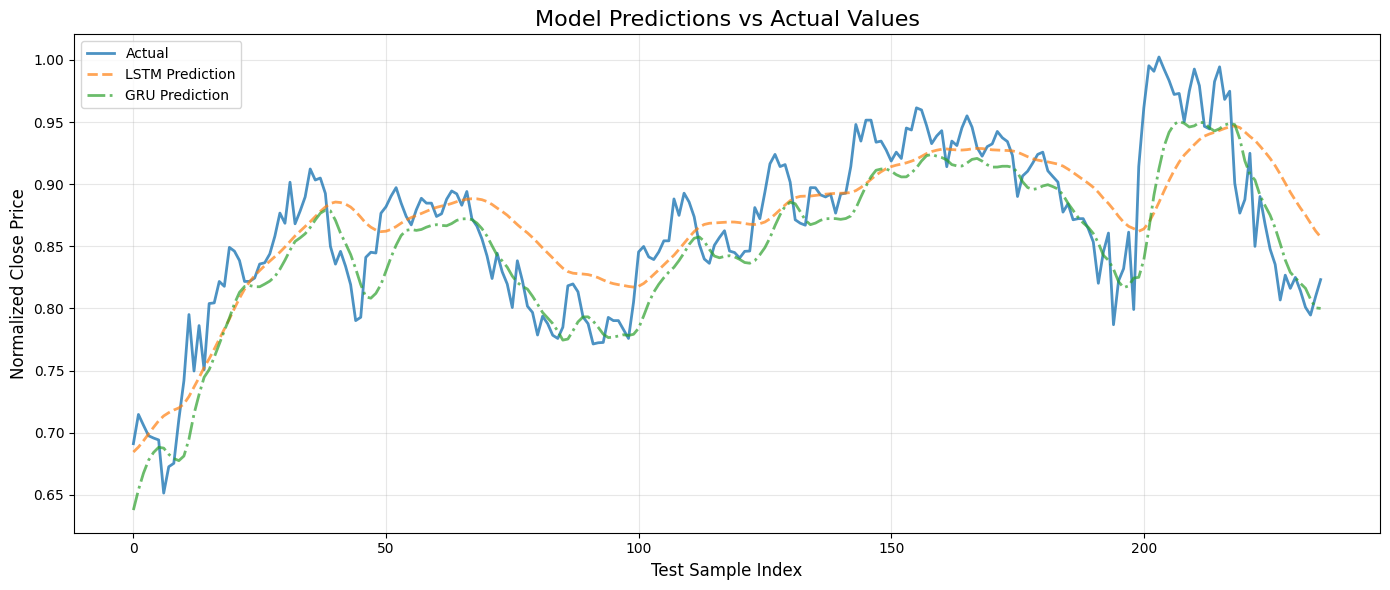

In [43]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df.index, predictions_df['LSTM_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.plot(predictions_df.index, predictions_df['GRU_Prediction'], label='GRU Prediction', linewidth=2, alpha=0.7, linestyle='-.')

plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


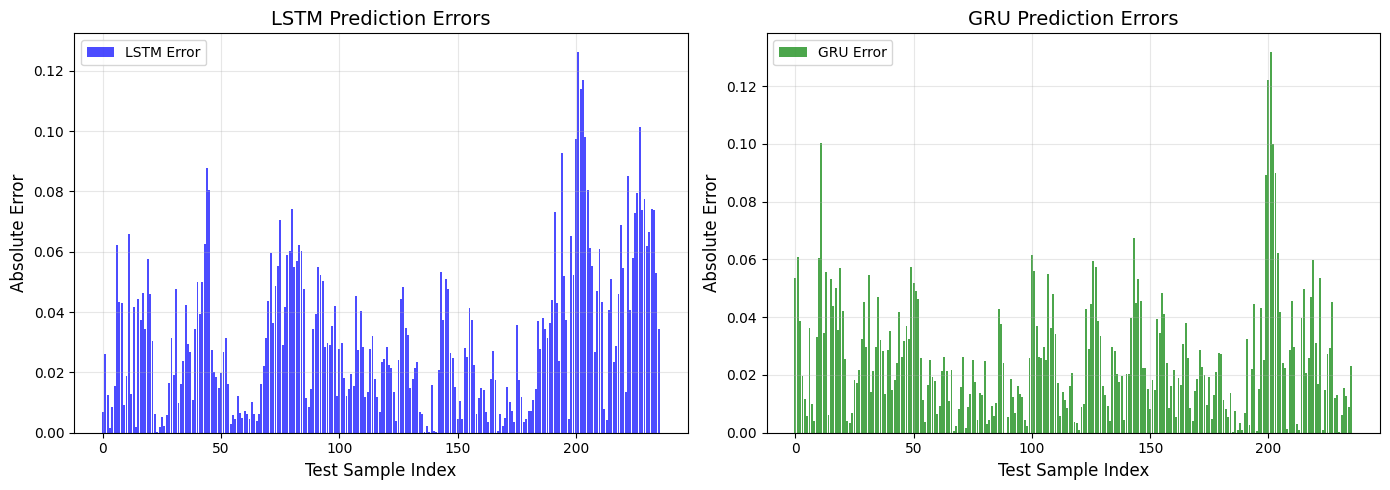

In [44]:
# Plot prediction errors
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
lstm_errors = np.abs(predictions_df['Actual'] - predictions_df['LSTM_Prediction'])
plt.bar(range(len(lstm_errors)), lstm_errors, alpha=0.7, color='blue', label='LSTM Error')
plt.title('LSTM Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
gru_errors = np.abs(predictions_df['Actual'] - predictions_df['GRU_Prediction'])
plt.bar(range(len(gru_errors)), gru_errors, alpha=0.7, color='green', label='GRU Error')
plt.title('GRU Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 13: Scatter Plot - Predicted vs Actual

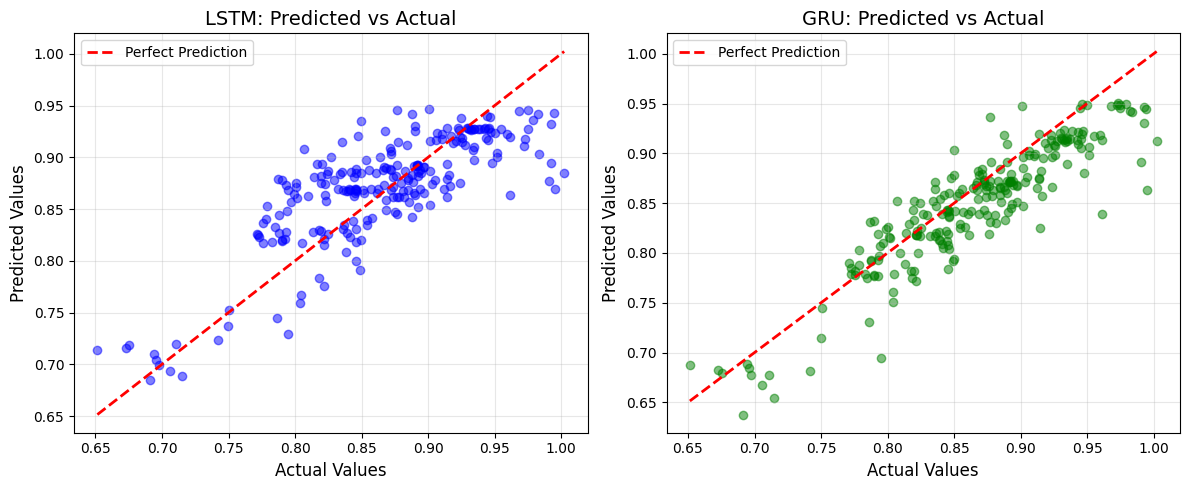

In [45]:
# Scatter plot for LSTM
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(predictions_df['Actual'], predictions_df['LSTM_Prediction'], alpha=0.5, color='blue')
plt.plot([predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         [predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('LSTM: Predicted vs Actual', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Scatter plot for GRU
plt.subplot(1, 2, 2)
plt.scatter(predictions_df['Actual'], predictions_df['GRU_Prediction'], alpha=0.5, color='green')
plt.plot([predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         [predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('GRU: Predicted vs Actual', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

In this notebook, we:

1. ✅ **Loaded** Adani Ports stock data
2. ✅ **Explored** the data with visualizations
3. ✅ **Preprocessed** the data (cleaning, normalization, sequence creation)
4. ✅ **Built** LSTM and GRU neural network models
5. ✅ **Trained** both models with early stopping
6. ✅ **Evaluated** performance using RMSE, MAE, and R² Score
7. ✅ **Compared** the models visually

### Key Takeaways:
- Both LSTM and GRU models can learn patterns in time series data
- GRU is computationally more efficient but LSTM may capture longer dependencies
- The model with higher R² Score and lower RMSE/MAE performs better
- Early stopping prevents overfitting by monitoring validation loss